In [47]:
import json

with open('../dados/transacoes_treino.json') as f:
    transacoes = json.load(f)

In [48]:
print(json.dumps(transacoes[0], indent=2, ensure_ascii=False))

{
  "id": 1,
  "valor": 2502.88,
  "data": "2025-07-01",
  "hora": "00:18",
  "dia_semana": "Tuesday",
  "categoria": "eletronicos",
  "conta": "45678-9",
  "cidade": "Cabo de Santo Agostinho",
  "estado": "PE",
  "pais": "Brasil",
  "latitude": -8.283989,
  "longitude": -35.030414,
  "tipo_transacao": "transferencia",
  "dispositivo": "caixa_eletronico",
  "estabelecimento": "Amazon BR",
  "tentativas": 2,
  "ip_origem": "191.55.206.133",
  "is_fraude": 1
}


## Vamos testar com Pandas

!pip install pandas


In [51]:
import pandas as pd

df = pd.read_json('../dados/transacoes_treino.json')
df.head()

,id,valor,data,hora,dia_semana,categoria,conta,cidade,estado,pais,latitude,longitude,tipo_transacao,dispositivo,estabelecimento,tentativas,ip_origem,is_fraude
0,1,2502.88,2025-07-01,00:18,Tuesday,eletronicos,45678-9,Cabo de Santo Agostinho,PE,Brasil,-8.283989,-35.030414,transferencia,caixa_eletronico,Amazon BR,2,191.55.206.133,1
1,2,8015.76,2025-07-01,00:46,Tuesday,eletronicos,22222-2,Brasilia,DF,Brasil,-15.783659,-47.888869,pix,app_mobile,Transferencia Internacional - Brasilia,2,91.134.65.177,1
2,3,801.95,2025-07-01,06:13,Tuesday,servicos,88888-8,Recife,PE,Brasil,-8.063469,-34.874367,debito,web,Lavanderia Clean,1,191.55.128.33,0
3,4,95.90,2025-07-01,07:17,Tuesday,lazer,77777-7,Camaragibe,PE,Brasil,-8.027728,-34.989240,pix,app_mobile,Netflix,1,177.38.101.132,0
4,5,5277.72,2025-07-01,07:35,Tuesday,moradia,88888-8,Recife,PE,Brasil,-8.055950,-34.878075,pix,app_mobile,Energisa PE,1,200.175.227.223,0


In [52]:
df.dtypes

id                   int64
valor              float64
data                object
hora                object
dia_semana          object
categoria           object
conta               object
cidade              object
estado              object
pais                object
latitude           float64
longitude          float64
tipo_transacao      object
dispositivo         object
estabelecimento     object
tentativas           int64
ip_origem           object
is_fraude            int64
dtype: object

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               30000 non-null  int64  
 1   valor            30000 non-null  float64
 2   data             30000 non-null  object 
 3   hora             30000 non-null  object 
 4   dia_semana       30000 non-null  object 
 5   categoria        30000 non-null  object 
 6   conta            30000 non-null  object 
 7   cidade           30000 non-null  object 
 8   estado           30000 non-null  object 
 9   pais             30000 non-null  object 
 10  latitude         30000 non-null  float64
 11  longitude        30000 non-null  float64
 12  tipo_transacao   30000 non-null  object 
 13  dispositivo      30000 non-null  object 
 14  estabelecimento  30000 non-null  object 
 15  tentativas       30000 non-null  int64  
 16  ip_origem        30000 non-null  object 
 17  is_fraude   

In [54]:
df.describe()

,id,valor,latitude,longitude,tentativas,is_fraude
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,727.496041,-8.020447,-35.411249,1.196967,0.080000
std,8660.398374,1307.972433,5.019647,5.509186,0.985429,0.271298
min,1.000000,4.020000,-34.626189,-80.213298,1.000000,0.000000
25%,7500.750000,63.727500,-8.122357,-35.021396,1.000000,0.000000
50%,15000.500000,194.800000,-8.046344,-34.886794,1.000000,0.000000
75%,22500.250000,620.042500,-8.015667,-34.869749,1.000000,0.000000
max,30000.000000,13766.740000,55.777756,37.637971,12.000000,1.000000


## Perguntas
1. Quantas fraudes temos no dataset?


In [55]:
df['is_fraude'].value_counts()

0    27600
1     2400
Name: is_fraude, dtype: int64

2. Qual a média de valor das transações normais vs fraudes?


In [57]:
df.groupby('is_fraude')['valor'].mean()

is_fraude
0     524.532029
1    3061.582188
Name: valor, dtype: float64

3.Em quais cidades acontecem mais fraudes?

In [61]:
fraudes = df[df['is_fraude'] == 1]

fraudes['cidade'].value_counts()


Recife                     470
Olinda                     199
Paulista                   177
Camaragibe                 161
Jaboatao                   156
Cabo de Santo Agostinho    114
Petrolina                  112
Caruaru                     87
Moscou                      83
Lisboa                      78
Rio de Janeiro              77
Buenos Aires                71
Curitiba                    70
Porto Alegre                70
Salvador                    67
Miami                       67
Sao Paulo                   67
Belo Horizonte              62
Lagos                       61
Brasilia                    52
Manaus                      51
Fortaleza                   48
Name: cidade, dtype: int64

4. Qual tipo de transação os fraudadores preferem?


In [62]:
fraudes['tipo_transacao'].value_counts()

credito          1133
pix               623
debito            533
transferencia     111
Name: tipo_transacao, dtype: int64

In [63]:
#Avançado
pd.crosstab(df["tipo_transacao"], df["is_fraude"], normalize="index").mul(100).round(2)

is_fraude,0,1
tipo_transacao,,
credito,87.84,12.16
debito,92.91,7.09
pix,93.95,6.05
transferencia,96.13,3.87


<AxesSubplot:xlabel='tipo_transacao'>

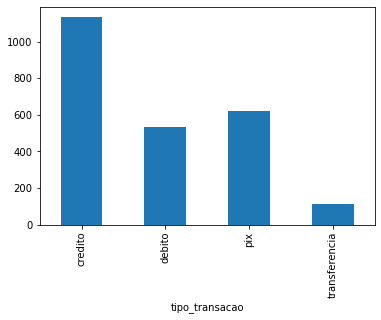

In [64]:
df.groupby('tipo_transacao')['is_fraude'].sum().plot(kind='bar')

In [ ]:
## Plots
df['is_fraude'].value_counts().plot(kind='bar')
df.groupby('is_fraude')['valor'].mean().plot(kind='bar')

## Desafio semanal
Usando pandas, carregue o dataset e responda:

Em que horário as fraudes acontecem?

"Qual conta tem mais fraudes

Dispositivo influencia?

Tem relação entre tentativas e fraude?

Qual conta tem o maior número total de transações?

Qual é o valor médio das transações por categoria?

Quantas transações aconteceram na madrugada (entre 00:00 e 05:59)?

Qual cidade fora de Pernambuco aparece mais vezes no dataset?

Qual a diferença entre o valor médio de transações feitas por `app_mobile` vs `terminal_fisico`?

6. **Crie uma nova coluna chamada `valor_suspeito`** que vale `True` se o valor da transação for maior que **2× a média da categoria** daquela transação, e `False` caso contrário.
   - Dica: calcular a média por categoria, depois usar `merge` ou `transform`
   - Depois, responda: **Quantas transações foram marcadas como `valor_suspeito`?**

7. **Escreva 3-5 linhas** (como comentário no código) respondendo:
> *"Olhando os dados que você explorou, quais colunas você acha que são mais úteis para identificar fraudes? Por quê?"*
